## Prepare Data

In [1]:
import pandas as pd
import os
from pathlib import Path

# Load CSV files into dictionary
csv_folder = "../raw/SevenPhishingEmailDataset"
csv_dict = {}

# Get all CSV files in the folder
csv_files = [f for f in os.listdir(csv_folder) if f.endswith('.csv')]

# Load each CSV file
for csv_file in csv_files:
    file_path = os.path.join(csv_folder, csv_file)
    df = pd.read_csv(file_path)
    
    # Add source column with filename (without extension)
    filename_without_ext = os.path.splitext(csv_file)[0]
    df['source'] = filename_without_ext
    
    # Store in dictionary with filename as key
    csv_dict[csv_file] = df
    print(f"Loaded {csv_file}: {df.shape}")

# Create combined dataframe
df_combined = pd.DataFrame()

# Iterate through dictionary and concatenate only specific columns
for filename, df in csv_dict.items():
    # Select only the required columns if they exist
    columns_to_keep = []
    for col in ['subject', 'body', 'label', 'source']:
        if col in df.columns:
            columns_to_keep.append(col)
    
    if columns_to_keep:
        df_subset = df[columns_to_keep]
        df_combined = pd.concat([df_combined, df_subset], ignore_index=True)
        print(f"Added {filename}: {df_subset.shape}")
    else:
        print(f"Warning: {filename} doesn't have required columns")

print(f"\nCombined dataframe shape: {df_combined.shape}")
print(f"Columns: {df_combined.columns.tolist()}")
print(f"Sources: {df_combined['source'].unique()}")

Loaded Assassin.csv: (5809, 8)
Loaded CEAS-08.csv: (39154, 8)
Loaded Enron.csv: (29767, 4)
Loaded Ling.csv: (2859, 4)
Loaded TREC-07.csv: (53757, 8)
Added Assassin.csv: (5809, 4)
Added CEAS-08.csv: (39154, 4)
Added Enron.csv: (29767, 4)
Added Ling.csv: (2859, 4)
Added TREC-07.csv: (53757, 4)

Combined dataframe shape: (131346, 4)
Columns: ['subject', 'body', 'label', 'source']
Sources: ['Assassin' 'CEAS-08' 'Enron' 'Ling' 'TREC-07']


In [2]:
df_combined.head()

,subject,body,label,source
0,Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,Assassin
1,[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,Assassin
2,[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,Assassin
3,[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,Assassin
4,Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,Assassin


<Axes: >

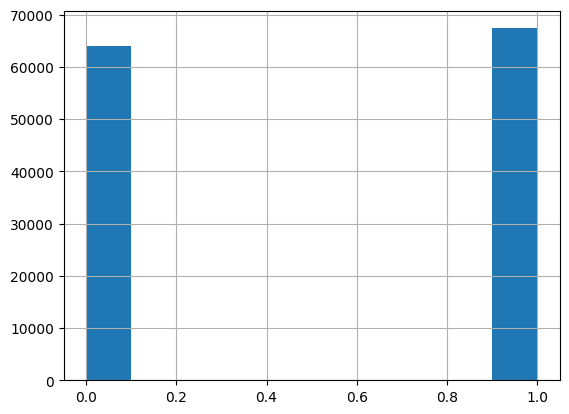

In [3]:
df_combined['label'].hist()

In [4]:
# Check label distribution for source 'Ling'
if 'Ling' in df_combined['source'].values:
    print(f"\nLabel distribution for source 'Ling':")
    ling_data = df_combined[df_combined['source'] == 'Ling']
    print(ling_data['label'].value_counts())
    print(f"\nLabel distribution (percentages):")
    print(ling_data['label'].value_counts(normalize=True) * 100)


Label distribution for source 'Ling':
label
0    2401
1     458
Name: count, dtype: int64

Label distribution (percentages):
label
0    83.980413
1    16.019587
Name: proportion, dtype: float64


In [5]:
# Check label distribution for source 'Ling'
if 'Enron' in df_combined['source'].values:
    print(f"\nLabel distribution for source 'Enron':")
    ling_data = df_combined[df_combined['source'] == 'Enron']
    print(ling_data['label'].value_counts())
    print(f"\nLabel distribution (percentages):")
    print(ling_data['label'].value_counts(normalize=True) * 100)


Label distribution for source 'Enron':
label
0    15791
1    13976
Name: count, dtype: int64

Label distribution (percentages):
label
0    53.048678
1    46.951322
Name: proportion, dtype: float64


In [6]:
df_combined.shape

(131346, 4)

In [7]:
df_combined = df_combined.drop_duplicates()
df_combined.shape

(131346, 4)

In [8]:
# so the label 1 is scam, label 0 is legitimate

In [9]:
df_combined.to_csv("../raw/five_email_phishing.csv.gz", index=False, compression='gzip', encoding='utf-8')